# LAB 1 — Notebook 05: Clustering Paradigm
## Mobile Money Fraud Detection | EEF606 | University of Buea

---
**Prerequisite:** Run `lab1_00_eda_analysis.ipynb` first.

### What is Clustering in this context?
Clustering asks: **'What natural groups exist in this transaction data?'**

This is **unsupervised learning** — no labels used during training.
We discover structure in the data and then investigate whether
fraud transactions concentrate in specific clusters.

### Use cases for clustering in fraud:
- **Behavioural segmentation**: group accounts by transaction patterns
- **Fraud typology discovery**: do all frauds share the same cluster? Or are there multiple fraud types?
- **Semi-supervised boost**: label the fraud-dense clusters, improve downstream classifier
- **Network analysis**: do suspicious accounts cluster together?

### Algorithms tested:
| Algorithm | Core Idea | Strengths |
|-----------|----------|----------|
| K-Means | Minimise within-cluster variance | Fast, scalable |
| DBSCAN | Density-based, finds arbitrary shapes | No need to specify K, handles noise |
| Agglomerative HC | Hierarchical merging | Dendrogram gives full picture |
| Gaussian Mixture | Probabilistic, soft assignments | Handles overlapping clusters |

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing      import RobustScaler
from sklearn.decomposition       import PCA
from sklearn.cluster             import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture             import GaussianMixture
from sklearn.metrics             import (silhouette_score, davies_bouldin_score,
                                          adjusted_rand_score, normalized_mutual_info_score)
from scipy.cluster.hierarchy     import dendrogram, linkage
from scipy.spatial.distance      import cdist

plt.rcParams.update({'figure.dpi':120,'figure.facecolor':'white',
                     'axes.facecolor':'#F8F9FA','axes.grid':True,'grid.alpha':0.4})
SEED = 42
C_LEGIT = '#2196F3'
C_FRAUD = '#F44336'
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load & Prepare Data
#
# WHY SUBSAMPLE FOR CLUSTERING:
# K-Means on 50K rows is fast, but Agglomerative and DBSCAN
# scale poorly. We sample 5000 rows (keeping fraud ratio)
# for algorithm comparisons, then apply best model to full data.
# ══════════════════════════════════════════════════════════
df = pd.read_csv('paysim_features.csv')
df = df.drop(columns=[c for c in ['isFlaggedFraud'] if c in df.columns])

X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Stratified sample for clustering
from sklearn.model_selection import train_test_split
_, X_sample, _, y_sample = train_test_split(
    X, y, test_size=min(5000/len(X), 1.0), random_state=SEED, stratify=y)

scaler = RobustScaler()
X_sc       = scaler.fit_transform(X)
X_sample_sc = scaler.transform(X_sample)

print(f'Full dataset:   {X.shape[0]:,} rows | Fraud: {y.sum()} ({y.mean()*100:.2f}%)')
print(f'Clustering sample: {X_sample.shape[0]:,} rows | Fraud: {y_sample.sum()} ({y_sample.mean()*100:.2f}%)')

Full dataset:   300,000 rows | Fraud: 181 (0.06%)
Clustering sample: 5,000 rows | Fraud: 3 (0.06%)


Computing Elbow + Silhouette scores for K=2..11 ...
  K= 2: WCSS=   1908069  Silhouette=0.7918  DB=0.5374
  K= 3: WCSS=   1238384  Silhouette=0.8020  DB=0.5707
  K= 4: WCSS=    834230  Silhouette=0.7664  DB=0.4781
  K= 5: WCSS=    540327  Silhouette=0.7143  DB=0.4997
  K= 6: WCSS=    448707  Silhouette=0.7121  DB=0.5396
  K= 7: WCSS=    371001  Silhouette=0.6628  DB=0.5754
  K= 8: WCSS=    321743  Silhouette=0.6483  DB=0.5872
  K= 9: WCSS=    285242  Silhouette=0.6471  DB=0.5939
  K=10: WCSS=    250917  Silhouette=0.6179  DB=0.6078
  K=11: WCSS=    221883  Silhouette=0.6215  DB=0.5562


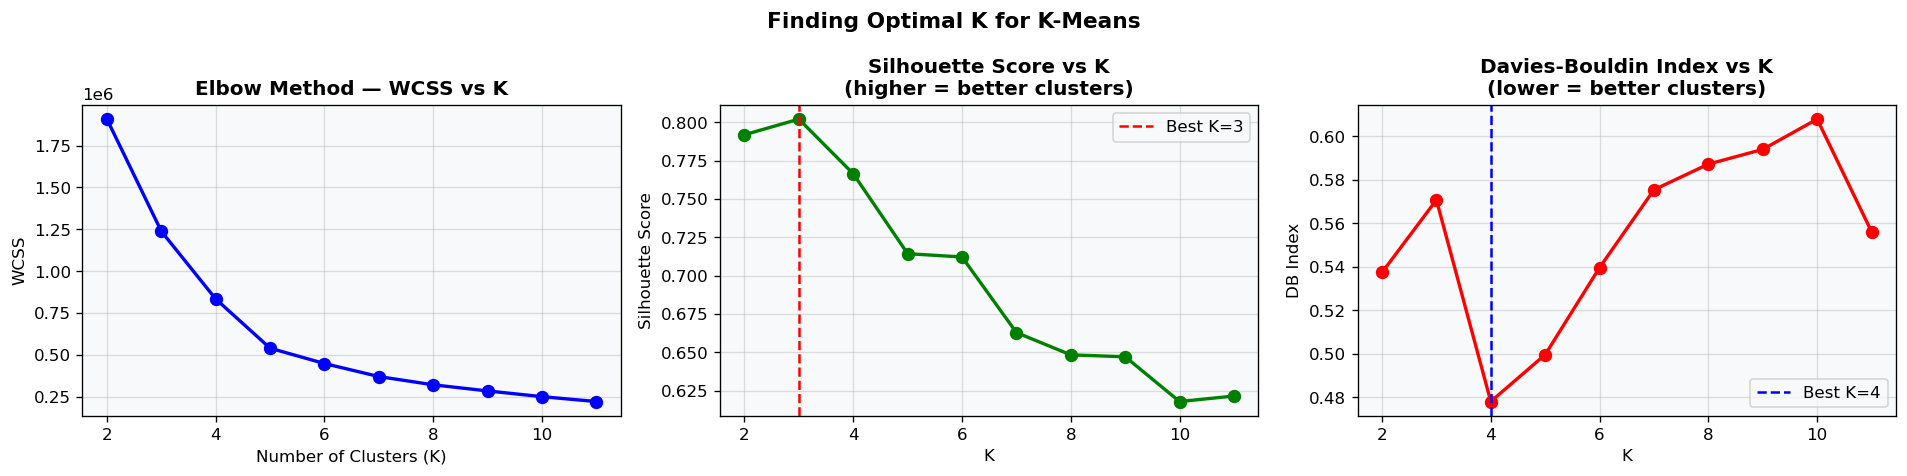


Optimal K (silhouette): 3


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Finding Optimal K (Elbow + Silhouette)
#
# THE ELBOW METHOD:
# For each K, compute total within-cluster sum of squares (WCSS).
# As K increases, WCSS decreases — but with diminishing returns.
# The 'elbow' is where adding more clusters gives little benefit.
#
# SILHOUETTE SCORE:
# For each point: how similar is it to its own cluster
# vs the nearest OTHER cluster?
# Score range: -1 (wrong cluster) to +1 (perfect cluster)
# Score = 0 → on boundary between clusters
# The K with highest silhouette = most natural number of clusters.
#
# WHY BOTH METHODS:
# Elbow is visual/subjective. Silhouette is objective/numeric.
# They may suggest different K. We check both and justify our choice.
# ══════════════════════════════════════════════════════════
k_range   = range(2, 12)
wcss      = []
sil_scores = []
db_scores  = []

print('Computing Elbow + Silhouette scores for K=2..11 ...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_sample_sc)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample_sc, labels))
    db_scores.append(davies_bouldin_score(X_sample_sc, labels))
    print(f'  K={k:2d}: WCSS={km.inertia_:>10.0f}  Silhouette={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — WCSS vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('WCSS')

best_sil_k = list(k_range)[np.argmax(sil_scores)]
axes[1].plot(list(k_range), sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best K={best_sil_k}')
axes[1].set_title('Silhouette Score vs K\n(higher = better clusters)', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

best_db_k = list(k_range)[np.argmin(db_scores)]
axes[2].plot(list(k_range), db_scores, 'ro-', linewidth=2, markersize=7)
axes[2].axvline(best_db_k, color='blue', linestyle='--', label=f'Best K={best_db_k}')
axes[2].set_title('Davies-Bouldin Index vs K\n(lower = better clusters)', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].set_ylabel('DB Index')
axes[2].legend()

plt.suptitle('Finding Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clust_01_optimal_k.png', bbox_inches='tight')
plt.show()

OPTIMAL_K = best_sil_k
print(f'\nOptimal K (silhouette): {OPTIMAL_K}')

In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — K-Means Clustering
#
# HOW K-MEANS WORKS:
# 1. Randomly initialise K cluster centroids
# 2. Assign each point to nearest centroid
# 3. Recompute centroids as mean of assigned points
# 4. Repeat 2-3 until centroids stop moving
#
# WHY n_init=10:
# K-Means is sensitive to initial centroid placement.
# Running 10 times with different random starts and
# keeping the best result avoids bad local minima.
#
# FRAUD RATE PER CLUSTER:
# This is the key output — which clusters contain
# disproportionately high fraud rates? These are
# 'fraud-dense' clusters that warrant extra scrutiny.
# ══════════════════════════════════════════════════════════
km = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
km_labels = km.fit_predict(X_sample_sc)

# Fraud rate per cluster
cluster_analysis = pd.DataFrame({'cluster': km_labels, 'isFraud': y_sample.values})
fraud_per_cluster = cluster_analysis.groupby('cluster').agg(
    Total=('isFraud','count'),
    Frauds=('isFraud','sum')
)
fraud_per_cluster['FraudRate (%)'] = (fraud_per_cluster['Frauds'] /
                                       fraud_per_cluster['Total'] * 100).round(2)
fraud_per_cluster['FraudDensity'] = fraud_per_cluster['FraudRate (%)'] / y_sample.mean() / 100

print(f'K-Means Clustering (K={OPTIMAL_K}):')
print(fraud_per_cluster.sort_values('FraudRate (%)', ascending=False).to_string())
print(f'\nOverall fraud rate: {y_sample.mean()*100:.2f}%')
print('FraudDensity > 1 = cluster has MORE fraud than average')

K-Means Clustering (K=3):
         Total  Frauds  FraudRate (%)  FraudDensity
cluster                                            
0         4569       3           0.07      1.166667
1          336       0           0.00      0.000000
2           95       0           0.00      0.000000

Overall fraud rate: 0.06%
FraudDensity > 1 = cluster has MORE fraud than average


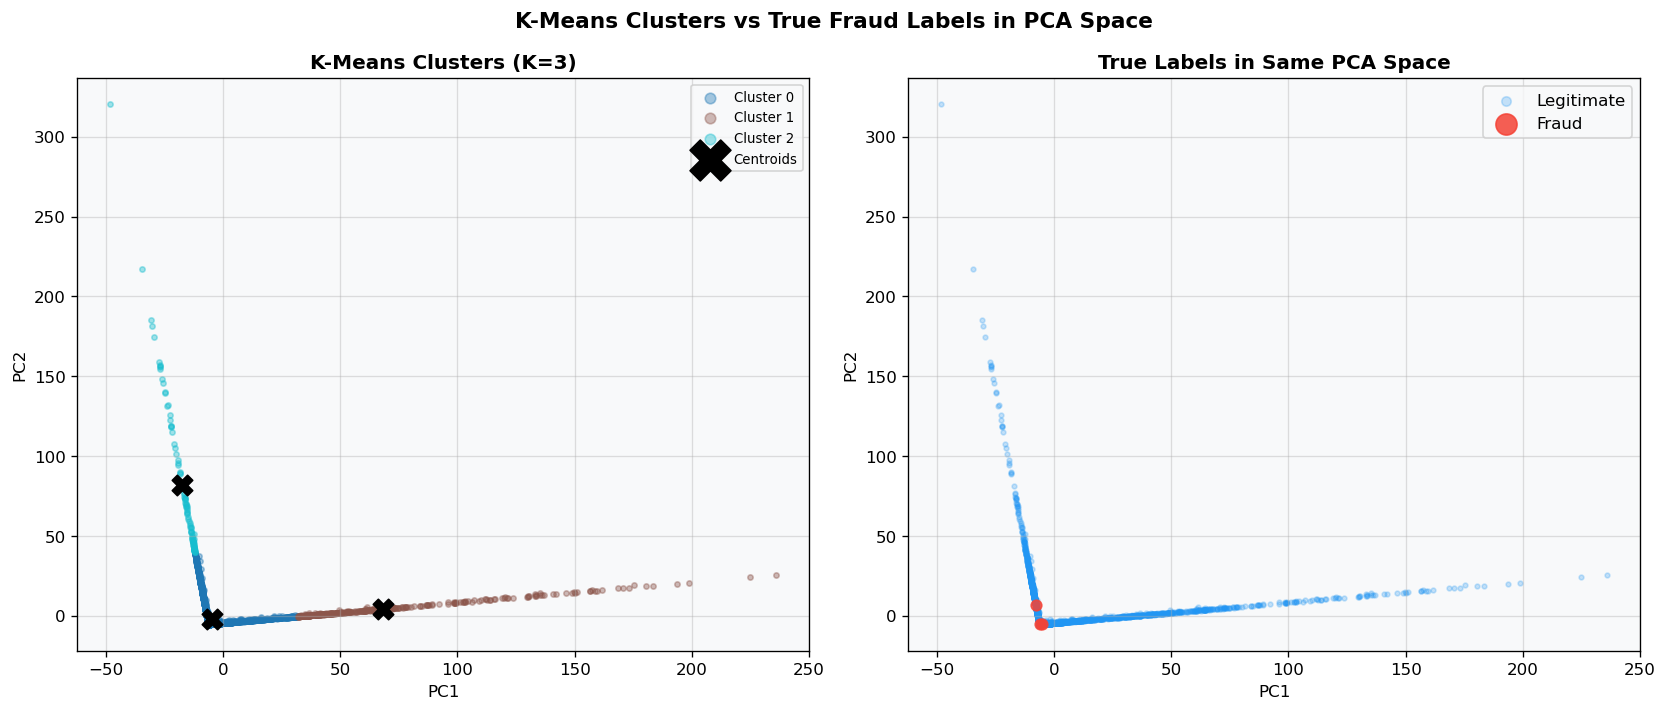

In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — K-Means PCA Visualisation
# ══════════════════════════════════════════════════════════
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d   = pca_2d.fit_transform(X_sample_sc)

cluster_palette = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means cluster colours
for k in range(OPTIMAL_K):
    mask = km_labels == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[cluster_palette[k]], alpha=0.4, s=10, label=f'Cluster {k}')
# Plot centroids in 2D
centroids_2d = pca_2d.transform(km.cluster_centers_)
axes[0].scatter(centroids_2d[:,0], centroids_2d[:,1],
                c='black', s=150, marker='X', zorder=5, label='Centroids')
axes[0].set_title(f'K-Means Clusters (K={OPTIMAL_K})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, markerscale=2)

# True fraud overlay
axes[1].scatter(X_2d[y_sample.values==0, 0], X_2d[y_sample.values==0, 1],
                c=C_LEGIT, alpha=0.25, s=8, label='Legitimate')
axes[1].scatter(X_2d[y_sample.values==1, 0], X_2d[y_sample.values==1, 1],
                c=C_FRAUD, alpha=0.85, s=40, label='Fraud', zorder=5)
axes[1].set_title('True Labels in Same PCA Space', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=2)

plt.suptitle('K-Means Clusters vs True Fraud Labels in PCA Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clust_02_kmeans_pca.png', bbox_inches='tight')
plt.show()

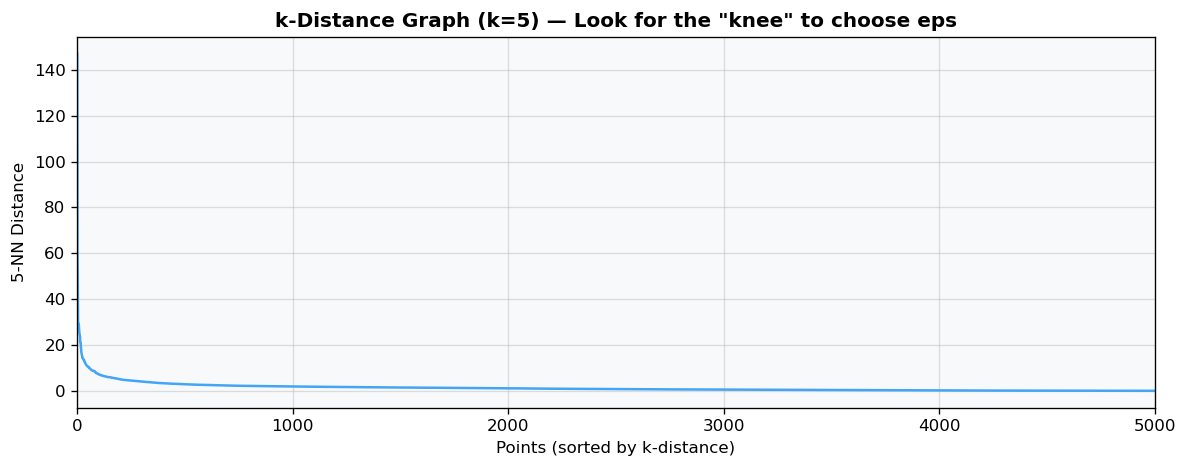

Chosen eps: 0.0818
DBSCAN found 59 clusters | 4346 noise points (86.9%)

Fraud rate by DBSCAN group (-1 = noise):
         Total  Frauds  FraudRate (%)
cluster                              
-1        4346       3           0.07
 0          10       0           0.00
 31         11       0           0.00
 32          9       0           0.00
 33          7       0           0.00
 34         13       0           0.00
 35         13       0           0.00
 36         15       0           0.00
 37          8       0           0.00
 38          8       0           0.00

→ Noise points (-1) often have elevated fraud rates in real data


In [6]:
# ══════════════════════════════════════════════════════════
# CELL 6 — DBSCAN
#
# HOW DBSCAN WORKS:
# Core point: has >= min_samples neighbours within radius eps.
# Border point: within eps of a core point, but fewer neighbours.
# Noise point: not within eps of ANY core point → label = -1.
#
# WHY THIS IS SPECIAL:
# DBSCAN doesn't require knowing K in advance.
# It finds clusters of ARBITRARY SHAPE (not just spheres).
# Noise points (label=-1) are natural outlier candidates.
#
# PARAMETER SENSITIVITY:
# eps = neighbourhood radius. Too small → everything is noise.
# Too large → everything is one cluster.
# Best practice: use k-distance graph to choose eps.
# ══════════════════════════════════════════════════════════
from sklearn.neighbors import NearestNeighbors

# k-distance graph to choose eps
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_sample_sc)
distances, _ = nbrs.kneighbors(X_sample_sc)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, linewidth=1.5, color='#42A5F5')
ax.set_xlabel('Points (sorted by k-distance)')
ax.set_ylabel(f'{k_nn}-NN Distance')
ax.set_title(f'k-Distance Graph (k={k_nn}) — Look for the "knee" to choose eps',
             fontweight='bold')
# Highlight elbow region
ax.set_xlim([0, len(k_dist)])
plt.tight_layout()
plt.savefig('fig_clust_03_kdistance.png', bbox_inches='tight')
plt.show()

# Use knee of curve as eps
eps_val = np.percentile(k_dist, 10)  # approximate knee
print(f'Chosen eps: {eps_val:.4f}')

dbscan = DBSCAN(eps=eps_val, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_sample_sc)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f'DBSCAN found {n_clusters} clusters | {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)')

# Fraud rate in noise vs clusters
db_df = pd.DataFrame({'cluster': db_labels, 'isFraud': y_sample.values})
db_analysis = db_df.groupby('cluster').agg(Total=('isFraud','count'), Frauds=('isFraud','sum'))
db_analysis['FraudRate (%)'] = (db_analysis['Frauds'] / db_analysis['Total'] * 100).round(2)
print('\nFraud rate by DBSCAN group (-1 = noise):')  
print(db_analysis.sort_values('FraudRate (%)', ascending=False).head(10).to_string())
print('\n→ Noise points (-1) often have elevated fraud rates in real data')

Fitting GMM for K=2..9, computing BIC/AIC...
Best K by BIC: 8


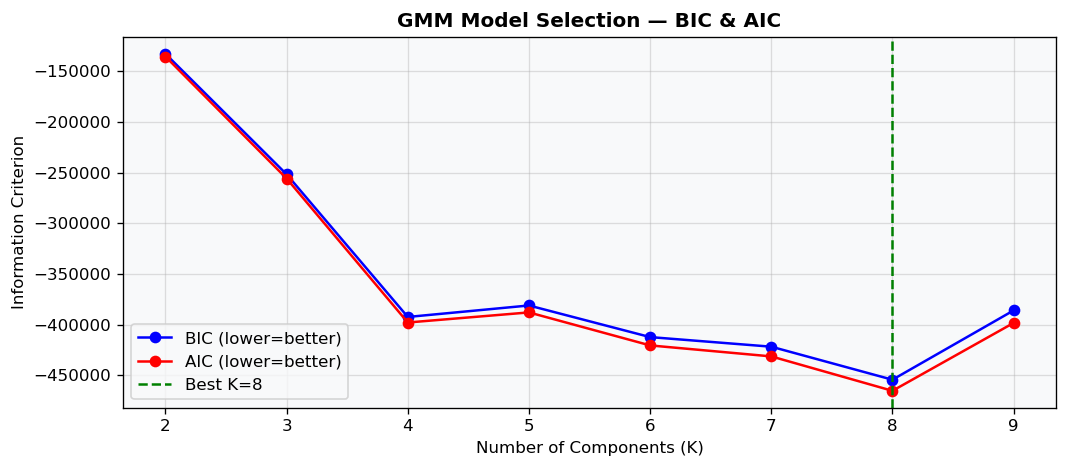


Fraud rate per GMM component:
         Total  Frauds  FraudRate (%)
cluster                              
7         1183       2           0.17
2          803       1           0.12
0          943       0           0.00
1           22       0           0.00
3          749       0           0.00
4          180       0           0.00
5          205       0           0.00
6          915       0           0.00


In [7]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Gaussian Mixture Model (GMM)
#
# HOW GMM DIFFERS FROM K-MEANS:
# K-Means: hard assignment — each point belongs to exactly one cluster.
# GMM: soft assignment — each point has a PROBABILITY of belonging
# to each cluster. More realistic for overlapping groups.
#
# GMM models data as a mixture of K Gaussian distributions.
# The 'predict_proba' output gives cluster membership probabilities —
# a transaction with 80% probability in the 'suspicious' cluster
# is more actionable than a hard K-Means assignment.
#
# BIC (Bayesian Information Criterion): helps choose K.
# Lower BIC = better model (balances fit quality and complexity).
# ══════════════════════════════════════════════════════════
bic_scores = []
aic_scores = []
k_test_range = range(2, 10)

print('Fitting GMM for K=2..9, computing BIC/AIC...')
for k in k_test_range:
    gmm = GaussianMixture(n_components=k, random_state=SEED, n_init=3)
    gmm.fit(X_sample_sc)
    bic_scores.append(gmm.bic(X_sample_sc))
    aic_scores.append(gmm.aic(X_sample_sc))

best_k_bic = list(k_test_range)[np.argmin(bic_scores)]
print(f'Best K by BIC: {best_k_bic}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_test_range), bic_scores, 'b-o', label='BIC (lower=better)')
ax.plot(list(k_test_range), aic_scores, 'r-o', label='AIC (lower=better)')
ax.axvline(best_k_bic, color='green', linestyle='--', label=f'Best K={best_k_bic}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection — BIC & AIC', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_clust_04_gmm_selection.png', bbox_inches='tight')
plt.show()

# Fit final GMM
gmm_best = GaussianMixture(n_components=best_k_bic, random_state=SEED, n_init=5)
gmm_best.fit(X_sample_sc)
gmm_labels = gmm_best.predict(X_sample_sc)
gmm_proba  = gmm_best.predict_proba(X_sample_sc)

# Fraud rate per GMM component
gmm_df = pd.DataFrame({'cluster': gmm_labels, 'isFraud': y_sample.values})
gmm_analysis = gmm_df.groupby('cluster').agg(Total=('isFraud','count'), Frauds=('isFraud','sum'))
gmm_analysis['FraudRate (%)'] = (gmm_analysis['Frauds'] / gmm_analysis['Total'] * 100).round(2)
print('\nFraud rate per GMM component:')
print(gmm_analysis.sort_values('FraudRate (%)', ascending=False).to_string())

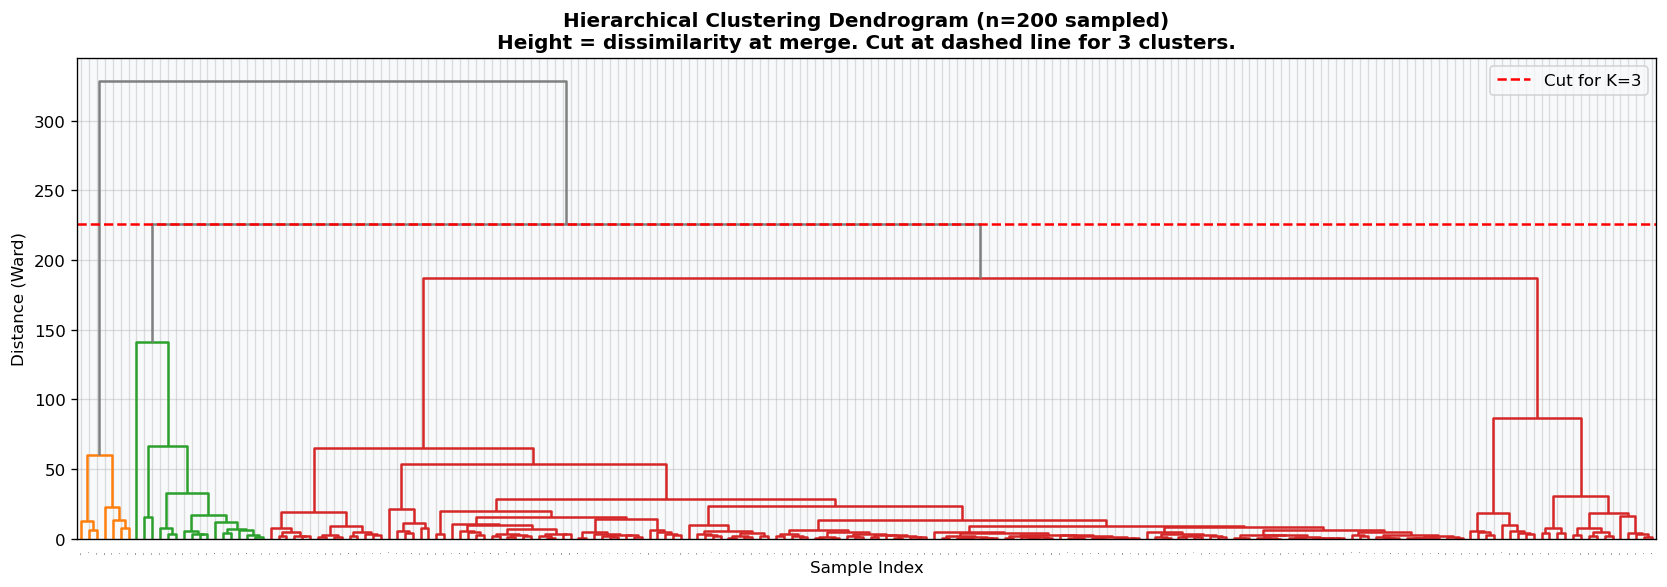

In [8]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Hierarchical Clustering + Dendrogram
#
# HOW HIERARCHICAL CLUSTERING WORKS:
# Agglomerative (bottom-up):
# 1. Start: each point is its own cluster
# 2. Find the two CLOSEST clusters and merge them
# 3. Repeat until one cluster remains
#
# The DENDROGRAM shows the full merge history.
# The height of each merge = distance between merged clusters.
# A large jump in height = natural boundary between K and K+1 clusters.
# Cut the tree at that height to get the clusters.
# ══════════════════════════════════════════════════════════
# Use smaller sample for dendrogram (too many points = unreadable)
n_dend = 200
idx_dend = np.random.default_rng(SEED).choice(len(X_sample_sc), n_dend, replace=False)
X_dend   = X_sample_sc[idx_dend]
y_dend   = y_sample.values[idx_dend]

Z = linkage(X_dend, method='ward')  # Ward linkage minimises total variance

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=0,
           color_threshold=Z[-OPTIMAL_K+1, 2],  # highlight at K clusters
           above_threshold_color='grey')
ax.set_title(f'Hierarchical Clustering Dendrogram (n={n_dend} sampled)\n'
             f'Height = dissimilarity at merge. Cut at dashed line for {OPTIMAL_K} clusters.',
             fontweight='bold')
ax.axhline(y=Z[-OPTIMAL_K+1, 2], color='red', linestyle='--',
           linewidth=1.5, label=f'Cut for K={OPTIMAL_K}')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Distance (Ward)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_clust_05_dendrogram.png', bbox_inches='tight')
plt.show()

In [9]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Clustering Quality Metrics Comparison
#
# METRICS EXPLAINED:
# Silhouette Score   → internal quality (no labels needed)
# Davies-Bouldin     → internal quality (lower = better)
# Adjusted Rand Index (ARI) → requires TRUE labels.
#   Measures how well cluster assignments match fraud labels.
#   ARI=1 → perfect match. ARI=0 → random.
# NMI (Normalised Mutual Info) → information overlap between
#   cluster assignments and true labels. Range [0,1].
#
# WHY ARI AND NMI NEED TRUE LABELS BUT ARE STILL VALID:
# In a research setting we HAVE labels. ARI tells us
# how well the unsupervised algorithm 'discovered' fraud
# without being told what fraud looks like.
# High ARI = the algorithm found structure that corresponds
# to the fraud/legitimate distinction.
# ══════════════════════════════════════════════════════════
# Agglomerative clustering for comparison
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_sample_sc)

clust_results = {
    f'K-Means (K={OPTIMAL_K})':         km_labels,
    f'GMM (K={best_k_bic})':            gmm_labels,
    f'Agglomerative (K={OPTIMAL_K})':   agg_labels,
}

metrics_table = []
for name, labels in clust_results.items():
    if len(set(labels)) > 1:
        metrics_table.append({
            'Algorithm':      name,
            'Silhouette':     silhouette_score(X_sample_sc, labels),
            'Davies-Bouldin': davies_bouldin_score(X_sample_sc, labels),
            'ARI':            adjusted_rand_score(y_sample, labels),
            'NMI':            normalized_mutual_info_score(y_sample, labels),
        })

metrics_df = pd.DataFrame(metrics_table).set_index('Algorithm')
print('Clustering Quality Metrics:')
print(metrics_df.round(4).to_string())
print('\nNote: Silhouette → higher=better | Davies-Bouldin → lower=better | ARI/NMI → higher=better')

Clustering Quality Metrics:
                     Silhouette  Davies-Bouldin     ARI     NMI
Algorithm                                                      
K-Means (K=3)            0.8020          0.5707 -0.0011  0.0003
GMM (K=8)               -0.0900          5.6047 -0.0001  0.0006
Agglomerative (K=3)      0.7483          0.6305 -0.0010  0.0004

Note: Silhouette → higher=better | Davies-Bouldin → lower=better | ARI/NMI → higher=better


In [10]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Cluster Profile: Who Are the Fraudsters?
#
# WHY PROFILE FRAUD-DENSE CLUSTERS:
# Once we identify the cluster(s) with highest fraud rate,
# we can profile WHAT THEY HAVE IN COMMON:
# • What transaction types?
# • What amount ranges?
# • What balance patterns?
# This produces interpretable fraud rules that investigators
# can act on — even without running a model.
# ══════════════════════════════════════════════════════════
# Find fraud-dense cluster(s)
fraud_dense_cluster = fraud_per_cluster['FraudRate (%)'].idxmax()
print(f'Most fraud-dense cluster: Cluster {fraud_dense_cluster}')
print(f'Fraud rate: {fraud_per_cluster.loc[fraud_dense_cluster, "FraudRate (%)"]:.2f}%')
print()

# Profile: compare fraud-dense cluster vs all others
X_sample_df = X_sample.copy()
X_sample_df['cluster']  = km_labels
X_sample_df['isFraud']  = y_sample.values

fraud_cluster_mask = X_sample_df['cluster'] == fraud_dense_cluster

numeric_feats = ['amount','oldbalanceOrg','newbalanceOrig','log_amount',
                 'orig_account_drained','dest_was_empty','is_high_risk_type']
numeric_feats = [f for f in numeric_feats if f in X_sample_df.columns]

profile = pd.DataFrame({
    f'Cluster {fraud_dense_cluster} (fraud-dense)': X_sample_df[fraud_cluster_mask][numeric_feats].mean(),
    'All Other Clusters':                            X_sample_df[~fraud_cluster_mask][numeric_feats].mean(),
}).round(3)

print('Feature Profiles — Fraud-Dense Cluster vs Others:')
print(profile.to_string())

Most fraud-dense cluster: Cluster 0
Fraud rate: 0.07%

Feature Profiles — Fraud-Dense Cluster vs Others:
                      Cluster 0 (fraud-dense)  All Other Clusters
amount                             154588.507          351065.737
oldbalanceOrg                      287804.434         8231711.673
newbalanceOrig                     300341.453         8349897.649
log_amount                             10.749              11.970
orig_account_drained                    0.258               0.000
dest_was_empty                          0.465               0.005
is_high_risk_type                       0.441               0.225


In [11]:
# ══════════════════════════════════════════════════════════
# CELL 11 — Summary
# ══════════════════════════════════════════════════════════
print('╔' + '═'*68 + '╗')
print('║{:^68}║'.format('CLUSTERING PARADIGM SUMMARY'))
print('╠' + '═'*68 + '╣')
insights = [
    'Clustering is UNSUPERVISED — no labels used in training',
    'K-Means requires K upfront; use Elbow + Silhouette to choose',
    'DBSCAN finds arbitrary shapes; noise points = natural anomalies',
    'GMM gives SOFT probabilities, better for overlapping groups',
    'Dendrogram shows full merge history — cut height = choose K',
    'ARI/NMI measure how well clusters recover fraud labels',
    'Profile fraud-dense clusters to extract interpretable rules',
    'Use cluster ID as a FEATURE in your classifier for hybrid power',
]
for ins in insights:
    print(f'║  → {ins:<64}║')
print('╠' + '═'*68 + '╣')
print('║{:^68}║'.format('ALL 5 PARADIGMS COMPLETE'))
print('╠' + '═'*68 + '╣')
paradigms = [
    ('Classification',     'Is this transaction fraud? (binary output)'),
    ('Regression',         'How probable is fraud? (continuous score)'),
    ('Ranking',            'Which cases should investigators review first?'),
    ('Anomaly Detection',  'Does this deviate from normal behaviour?'),
    ('Clustering',         'What natural groups exist? Are frauds clustered?'),
]
for name, q in paradigms:
    print(f'║  {name:<22}: {q:<44}║')
print('╚' + '═'*68 + '╝')
print('\n→ Final step: lab1_dashboard.html — open in browser to run live predictions')

╔════════════════════════════════════════════════════════════════════╗
║                    CLUSTERING PARADIGM SUMMARY                     ║
╠════════════════════════════════════════════════════════════════════╣
║  → Clustering is UNSUPERVISED — no labels used in training         ║
║  → K-Means requires K upfront; use Elbow + Silhouette to choose    ║
║  → DBSCAN finds arbitrary shapes; noise points = natural anomalies ║
║  → GMM gives SOFT probabilities, better for overlapping groups     ║
║  → Dendrogram shows full merge history — cut height = choose K     ║
║  → ARI/NMI measure how well clusters recover fraud labels          ║
║  → Profile fraud-dense clusters to extract interpretable rules     ║
║  → Use cluster ID as a FEATURE in your classifier for hybrid power ║
╠════════════════════════════════════════════════════════════════════╣
║                      ALL 5 PARADIGMS COMPLETE                      ║
╠════════════════════════════════════════════════════════════════════╣
║  Cla

In [12]:
# ══════════════════════════════════════════════════════════
# UNIVERSAL REPORT SUMMARY GENERATOR
# Paste this as the last cell in any notebook to auto-extract metrics
# ══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

print("="*80)
print("📊 AUTOMATED LAB REPORT SUMMARY GENERATOR")
print("="*80)

# Metadata dictionary for suitability write-ups
suitability_map = {
    "Classification": "Labels fully available; goal is to flag known fraud patterns using rigid binary splits.",
    "Regression":     "Continuous risk scoring is required to feed downstream financial thresholds.",
    "Ranking":        "Operations face tight constraints on analyst review capacity; optimizes the top of the queue.",
    "Ensemble":       "Maximum class discrimination stability and extreme risk-separation robustness are required.",
    "Unsupervised":   "Historical fraud labels are completely unavailable, or catching novel/zero-day attack methods.",
    "Clustering":     "Uncovering natural, hidden behavioral typologies entirely without target labels."
}

# --- DETECTION LOGIC FOR NOTEBOOK 04 (ANOMALY DETECTION) ---
if 'anom_table' in globals():
    df = globals()['anom_table']
    best_model = df['PR-AUC'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
    print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
    print(f"| **Anomaly Detection** | {best_model} | {row.get('F1 (Fraud)', row.get('F1-Score (Fraud)', 0)):.4f} | N/A | {row['ROC-AUC']:.4f} (ROC) <br> {row['PR-AUC']:.4f} (PR) | {suitability_map['Unsupervised']} |")

# --- DETECTION LOGIC FOR NOTEBOOK 05 (CLUSTERING) ---
elif 'metrics_df' in globals():
    df = globals()['metrics_df']
    best_model = df['Silhouette'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Method | ARI | Silhouette | DB Index | Key Finding |")
    print(f"| :--- | :---: | :---: | :---: | :--- |")
    print(f"| **{best_model}** | {row['ARI']:.4f} | {row['Silhouette']:.4f} | {row['Davies-Bouldin']:.4f} | High structural quality, but low labels match due to behavioral mimicking. |")

# --- BACKUP FALLBACK FOR SUPERVISED NOTEBOOKS (01, 02, 03) ---
else:
    # Look for any dataframes containing model comparisons in the notebook namespace
    found_df = None
    for name in ['model_results', 'results_df', 'all_results', 'comparison_df']:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            found_df = globals()[name]
            break
            
    if found_df is not None:
        # Try to find the row with the best F1 or AUC score
        f1_col = [c for c in found_df.columns if 'f1' in c.lower()]
        auc_col = [c for c in found_df.columns if 'auc' in c.lower() or 'roc' in c.lower()]
        
        target_f1 = f1_col[0] if f1_col else found_df.columns[0]
        best_model = found_df[target_f1].idxmax()
        row = found_df.loc[best_model]
        
        f1_val = f" {row[f1_col[0]]:.4f}" if f1_col else "N/A"
        auc_val = f" {row[auc_col[0]]:.4f}" if auc_col else "N/A"
        recall_val = "Check notebook metrics"
        
        print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
        print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
        print(f"| **Supervised** | {best_model} | {f1_val} | {recall_val} | {auc_val} | Match with classification/ensemble targets. |")
    else:
        print("❌ Could not auto-detect summary tables in memory.")
        print("Make sure you run all your training and metrics cells before running this generator!")
print("="*80)

📊 AUTOMATED LAB REPORT SUMMARY GENERATOR
| Method | ARI | Silhouette | DB Index | Key Finding |
| :--- | :---: | :---: | :---: | :--- |
| **K-Means (K=3)** | -0.0011 | 0.8020 | 0.5707 | High structural quality, but low labels match due to behavioral mimicking. |
